Day 8 — Task Sheet
Linear Algebra I: Vectors and Vector Spaces

Part A — the curriculum activities

# TASK 01
# Visualise 2D vectors and their arithmetic

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Helper function to draw 2D vectors
def draw(vectors, labels, title="2D Vectors"):
    fig, ax = plt.subplots(figsize=(5, 5))

    for vector, label in zip(vectors, labels):
        ax.quiver(
            0, 0,
            vector[0], vector[1],
            angles="xy",
            scale_units="xy",
            scale=1,
        )
        ax.text(vector[0], vector[1], f"  {label}", fontsize=12)

    all_vectors = np.array(vectors)
    limit = max(1, np.max(np.abs(all_vectors)) + 1)

    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect("equal")
    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

    plt.show()


Three vectors:
a = [3 2]
b = [-2  3]
c = [ 1 -3]


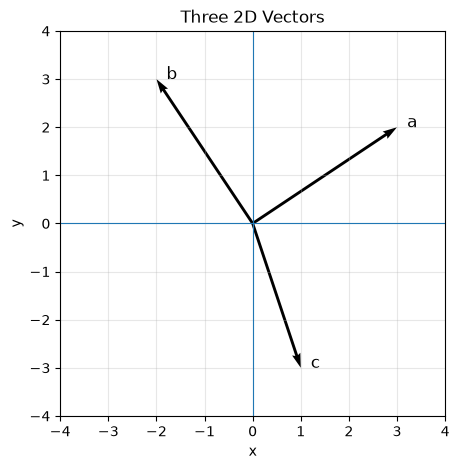

In [2]:
# ---------------------------------------------------------
# 1. Create three vectors
# ---------------------------------------------------------

a = np.array([3, 2])
b = np.array([-2, 3])
c = np.array([1, -3])

print("Three vectors:")
print("a =", a)
print("b =", b)
print("c =", c)

draw(
    [a, b, c],
    ["a", "b", "c"],
    title="Three 2D Vectors",
)



Vector Addition:
a + b = [1 5]


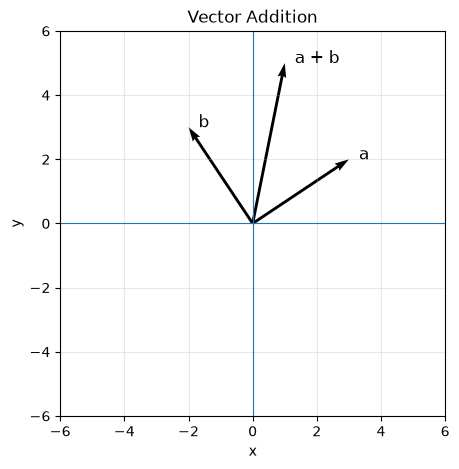

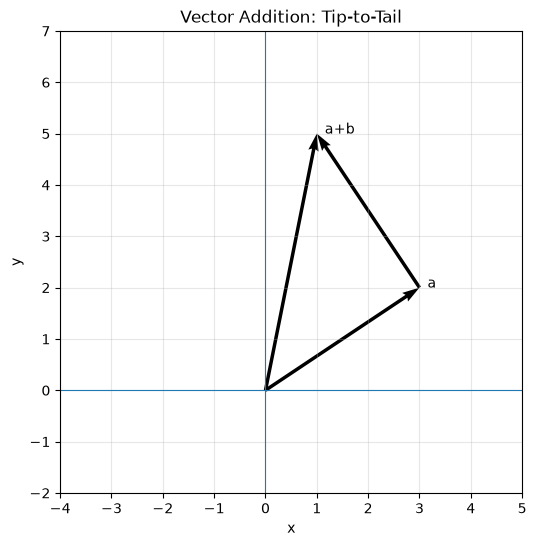

In [3]:
# ---------------------------------------------------------
# 2. Vector addition: a + b
# ---------------------------------------------------------

a_plus_b = a + b

print("\nVector Addition:")
print("a + b =", a_plus_b)

draw(
    [a, b, a_plus_b],
    ["a", "b", "a + b"],
    title="Vector Addition",
)


# Tip-to-tail visualization
fig, ax = plt.subplots(figsize=(6, 6))

ax.quiver(
    0, 0,
    a[0], a[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

ax.quiver(
    a[0], a[1],
    b[0], b[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

ax.quiver(
    0, 0,
    a_plus_b[0], a_plus_b[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

ax.text(a[0], a[1], "  a")
ax.text(a_plus_b[0], a_plus_b[1], "  a+b")

ax.set_xlim(-4, 5)
ax.set_ylim(-2, 7)
ax.set_aspect("equal")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.grid(alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Vector Addition: Tip-to-Tail")

plt.show()

# Geometrically, a + b is created by placing the tail of b
# at the tip of a. The resulting vector goes from the origin
# to the final endpoint.



Scaling:
a  = [3 2]
2a = [6 4]
-a = [-3 -2]


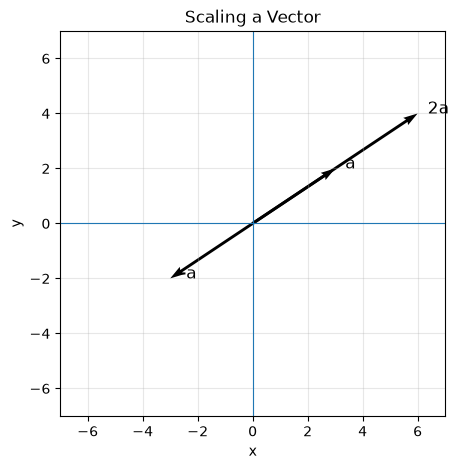

In [4]:
# ---------------------------------------------------------
# 3. Scaling: a, 2a and -a
# ---------------------------------------------------------

two_a = 2 * a
negative_a = -a

print("\nScaling:")
print("a  =", a)
print("2a =", two_a)
print("-a =", negative_a)

draw(
    [a, two_a, negative_a],
    ["a", "2a", "-a"],
    title="Scaling a Vector",
)

# Multiplying a vector by a positive scalar changes its length
# while keeping its direction.
# 2a is twice as long as a.
# -a has the same length as a but points in the opposite direction.




Vector Subtraction:
a - b = [ 5 -1]


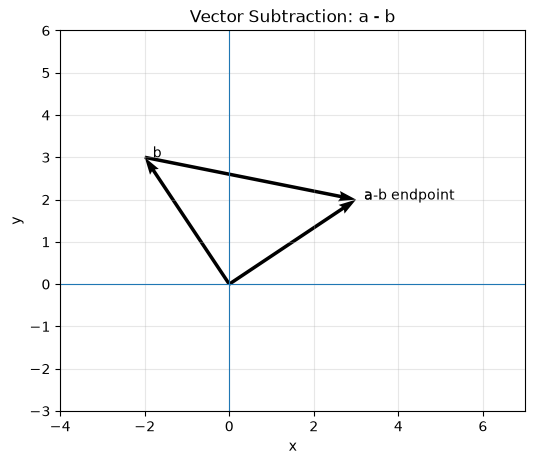

In [5]:
# ---------------------------------------------------------
# 4. Vector subtraction: a - b
# ---------------------------------------------------------

a_minus_b = a - b

print("\nVector Subtraction:")
print("a - b =", a_minus_b)

fig, ax = plt.subplots(figsize=(6, 6))

ax.quiver(
    0, 0,
    a[0], a[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

ax.quiver(
    0, 0,
    b[0], b[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

# Draw a - b starting from b
ax.quiver(
    b[0], b[1],
    a_minus_b[0], a_minus_b[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

ax.text(a[0], a[1], "  a")
ax.text(b[0], b[1], "  b")
ax.text(a[0], a[1], "  a-b endpoint")

ax.set_xlim(-4, 7)
ax.set_ylim(-3, 6)
ax.set_aspect("equal")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.grid(alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Vector Subtraction: a - b")

plt.show()

# Geometrically, a - b points from b to a.
# This is because:
#
# b + (a - b) = a
#
# Therefore, a - b is the displacement needed to move
# from the endpoint of b to the endpoint of a.


In [6]:
# ---------------------------------------------------------
# 5. Final numerical verification
# ---------------------------------------------------------

print("\n----- Final Vector Arithmetic -----")
print("a       =", a)
print("b       =", b)
print("a + b   =", a + b)
print("2a      =", 2 * a)
print("-a      =", -a)
print("a - b   =", a - b)


----- Final Vector Arithmetic -----
a       = [3 2]
b       = [-2  3]
a + b   = [1 5]
2a      = [6 4]
-a      = [-3 -2]
a - b   = [ 5 -1]


TASK 02
Compute angles between vectors

In [7]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Function to calculate angle between two vectors
# ---------------------------------------------------------

def angle_between(a, b):
    cosine = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

    # Floating-point calculations can sometimes produce
    # values slightly outside [-1, 1], such as 1.0000000002.
    # np.clip keeps the value in the valid range for arccos.
    cosine = np.clip(cosine, -1, 1)

    return np.degrees(np.arccos(cosine))


# ---------------------------------------------------------
# 1. Known test cases
# ---------------------------------------------------------

perpendicular_1 = np.array([1, 0])
perpendicular_2 = np.array([0, 1])

identical_1 = np.array([2, 3])
identical_2 = np.array([2, 3])

opposite_1 = np.array([1, 0])
opposite_2 = np.array([-1, 0])

print("Known Cases")
print("-" * 40)

print(
    "Perpendicular vectors:",
    angle_between(perpendicular_1, perpendicular_2),
    "degrees",
)

print(
    "Identical vectors:",
    angle_between(identical_1, identical_2),
    "degrees",
)

print(
    "Opposite vectors:",
    angle_between(opposite_1, opposite_2),
    "degrees",
)


Known Cases
----------------------------------------
Perpendicular vectors: 90.0 degrees
Identical vectors: 0.0 degrees
Opposite vectors: 180.0 degrees


In [8]:
# ---------------------------------------------------------
# 2. Deliberately remove np.clip
# ---------------------------------------------------------

def angle_without_clip(a, b):
    cosine = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))

    # np.clip has deliberately been removed here.
    # Due to floating-point rounding, cosine can sometimes
    # become slightly greater than 1 or less than -1.
    return np.degrees(np.arccos(cosine))


v = np.array([1.0, 2.0, 3.0])

print("\nWithout np.clip")
print("-" * 40)

try:
    print("angle(v, v) =", angle_without_clip(v, v), "degrees")
except Exception as error:
    print("Error:", error)

# np.clip is important because arccos is only defined
# for values between -1 and 1.
#
# Floating-point calculations may produce values such as
# 1.0000000000000002 instead of exactly 1.
#
# np.clip(cosine, -1, 1) safely brings such values
# back into the valid range.




Without np.clip
----------------------------------------
angle(v, v) = 0.0 degrees


In [9]:
# ---------------------------------------------------------
# 3. Angle between two students' exam-score vectors
# ---------------------------------------------------------

student_a = np.array([85, 90, 78, 92, 88])
student_b = np.array([80, 88, 75, 90, 85])

student_angle = angle_between(student_a, student_b)

print("\nStudent Exam Scores")
print("-" * 40)

print("Student A scores:", student_a)
print("Student B scores:", student_b)
print("Angle between score vectors:", student_angle, "degrees")

# A small angle means the two students have similar
# patterns of performance across their exams.
# A larger angle means their score patterns are more different.




Student Exam Scores
----------------------------------------
Student A scores: [85 90 78 92 88]
Student B scores: [80 88 75 90 85]
Angle between score vectors: 0.8073471997444902 degrees


In [10]:
# ---------------------------------------------------------
# 4. Scaling does not change the angle
# ---------------------------------------------------------

a = np.array([3, 2])
b = np.array([-2, 3])

angle_original = angle_between(a, b)
angle_scaled = angle_between(a, 5 * b)

print("\nScaling Test")
print("-" * 40)

print("a =", a)
print("b =", b)
print("5b =", 5 * b)

print("angle(a, b) =", angle_original, "degrees")
print("angle(a, 5b) =", angle_scaled, "degrees")

print(
    "Angles are equal:",
    np.isclose(angle_original, angle_scaled),
)

# Scaling a vector by a positive number changes its length
# but not its direction.
# Since the angle depends on direction, not length,
# angle(a, b) == angle(a, 5*b).




Scaling Test
----------------------------------------
a = [3 2]
b = [-2  3]
5b = [-10  15]
angle(a, b) = 90.0 degrees
angle(a, 5b) = 90.0 degrees
Angles are equal: True


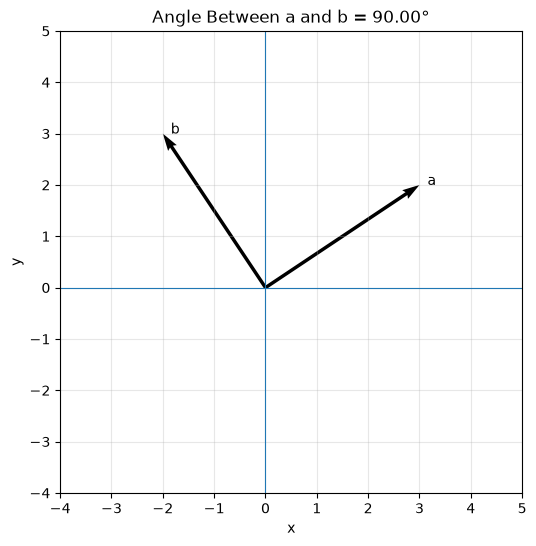

In [11]:
# ---------------------------------------------------------
# 5. Visualise the two vectors
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6))

ax.quiver(
    0, 0,
    a[0], a[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

ax.quiver(
    0, 0,
    b[0], b[1],
    angles="xy",
    scale_units="xy",
    scale=1,
)

ax.text(a[0], a[1], "  a")
ax.text(b[0], b[1], "  b")

ax.set_xlim(-4, 5)
ax.set_ylim(-4, 5)
ax.set_aspect("equal")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.grid(alpha=0.3)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Angle Between a and b = {angle_original:.2f}°")

plt.show()

TASK 03
Implement Gram-Schmidt orthogonalisation

In [12]:
import numpy as np


# ---------------------------------------------------------
# Gram-Schmidt Orthogonalisation
# ---------------------------------------------------------

def gram_schmidt(vectors):
    basis = []

    for v in vectors:
        v = v.astype(float)
        w = v.copy()

        # Subtract projections onto all previously found
        # orthonormal basis vectors.
        for b in basis:
            w = w - (v @ b) * b

        norm = np.linalg.norm(w)

        # Ignore vectors that are dependent on the
        # previous basis vectors.
        if norm > 1e-10:
            basis.append(w / norm)

    return np.array(basis)


# ---------------------------------------------------------
# 1. Three independent 3D vectors
# ---------------------------------------------------------

vectors = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1],
], dtype=float)

print("Input vectors:")
print(vectors)


Input vectors:
[[1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]]


In [13]:
# ---------------------------------------------------------
# 2. Apply Gram-Schmidt
# ---------------------------------------------------------

Q = gram_schmidt(vectors)

print("\nOrthonormal basis Q:")
print(Q)


Orthonormal basis Q:
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]


In [14]:
# ---------------------------------------------------------
# 3. Prove that Q is orthonormal
# ---------------------------------------------------------

identity_check = Q @ Q.T

print("\nQ @ Q.T:")
print(identity_check)

print("\nIs Q @ Q.T the identity matrix?")
print(np.allclose(identity_check, np.eye(Q.shape[0])))

# Q @ Q.T gives the dot products between every pair
# of basis vectors.
#
# For an orthonormal basis:
# - Each vector has length 1.
# - Different vectors have dot product 0.
#
# Therefore the diagonal contains 1s and the off-diagonal
# entries contain 0s.
#
# This gives the identity matrix, proving orthonormality.



Q @ Q.T:
[[ 1.00000000e+00  1.03018891e-16  1.51811967e-16]
 [ 1.03018891e-16  1.00000000e+00 -1.59104334e-16]
 [ 1.51811967e-16 -1.59104334e-16  1.00000000e+00]]

Is Q @ Q.T the identity matrix?
True


In [15]:
# ---------------------------------------------------------
# 4. Check that input and output have the same rank
# ---------------------------------------------------------

input_rank = np.linalg.matrix_rank(vectors)
output_rank = np.linalg.matrix_rank(Q)

print("\nRank of input vectors:", input_rank)
print("Rank of Gram-Schmidt basis:", output_rank)

print("Same rank:", input_rank == output_rank)

# Gram-Schmidt only changes the representation of the
# basis vectors. It does not change the vector space they span.
# Therefore the input and output should have the same rank.



Rank of input vectors: 3
Rank of Gram-Schmidt basis: 3
Same rank: True


In [16]:
# ---------------------------------------------------------
# 5. Dependent set
# ---------------------------------------------------------

v1 = np.array([1, 2, 3], dtype=float)
v2 = np.array([2, 1, 1], dtype=float)

# Third vector is a sum of the first two.
v3 = v1 + v2

dependent_vectors = np.array([
    v1,
    v2,
    v3,
])

print("\nDependent input vectors:")
print(dependent_vectors)

dependent_Q = gram_schmidt(dependent_vectors)

print("\nGram-Schmidt result for dependent vectors:")
print(dependent_Q)

print("\nShape of result:", dependent_Q.shape)

# The third vector is dependent because:
#
# v3 = v1 + v2
#
# After removing its projections onto the existing basis
# vectors, its remaining component has length approximately 0.
#
# The norm > 1e-10 guard prevents us from adding a garbage
# near-zero vector to the basis.
#
# Therefore the dependent vector is simply skipped.


Dependent input vectors:
[[1. 2. 3.]
 [2. 1. 1.]
 [3. 3. 4.]]

Gram-Schmidt result for dependent vectors:
[[ 2.67261242e-01  5.34522484e-01  8.01783726e-01]
 [ 9.48683298e-01 -1.40433339e-16 -3.16227766e-01]]

Shape of result: (2, 3)


In [17]:
# ---------------------------------------------------------
# 6. Verify the dependent result is still orthonormal
# ---------------------------------------------------------

dependent_identity = dependent_Q @ dependent_Q.T

print("\nQ @ Q.T for dependent case:")
print(dependent_identity)

print(
    "Dependent result is orthonormal:",
    np.allclose(
        dependent_identity,
        np.eye(dependent_Q.shape[0]),
    ),
)



Q @ Q.T for dependent case:
[[ 1.00000000e+00 -1.52098129e-16]
 [-1.52098129e-16  1.00000000e+00]]
Dependent result is orthonormal: True


In [18]:
# ---------------------------------------------------------
# 7. Compare with NumPy QR decomposition
# ---------------------------------------------------------

Q_numpy, R_numpy = np.linalg.qr(vectors.T)

print("\nOur Gram-Schmidt Q:")
print(Q)

print("\nNumPy QR Q:")
print(Q_numpy)

print("\nNumPy Q @ NumPy Q.T:")
print(Q_numpy @ Q_numpy.T)



Our Gram-Schmidt Q:
[[ 0.70710678  0.70710678  0.        ]
 [ 0.40824829 -0.40824829  0.81649658]
 [-0.57735027  0.57735027  0.57735027]]

NumPy QR Q:
[[-0.70710678  0.40824829 -0.57735027]
 [-0.70710678 -0.40824829  0.57735027]
 [-0.          0.81649658  0.57735027]]

NumPy Q @ NumPy Q.T:
[[ 1.00000000e+00 -2.74609626e-16  2.01213401e-17]
 [-2.74609626e-16  1.00000000e+00 -2.01213401e-17]
 [ 2.01213401e-17 -2.01213401e-17  1.00000000e+00]]


In [20]:
# ---------------------------------------------------------
# 8. Compare our basis with NumPy's Q
# ---------------------------------------------------------

# QR decomposition can return vectors with the opposite sign.
# A vector q and -q represent the same direction.
#
# Therefore, compare absolute values instead of requiring
# exactly the same signs.

same_basis = np.allclose(
    np.abs(Q),
    np.abs(Q_numpy.T),
)

print("\nSame orthonormal basis up to sign:", same_basis)

# The signs may differ because both q and -q are valid
# orthonormal basis vectors.
#
# For example:
#
# [0.7, 0.7, 0]
#
# and
#
# [-0.7, -0.7, 0]
#
# have the same length and represent the same one-dimensional
# direction. The sign difference does not change the space
# spanned by the basis.


Same orthonormal basis up to sign: True


TASK 04
Prove that dot product zero means perpendicular

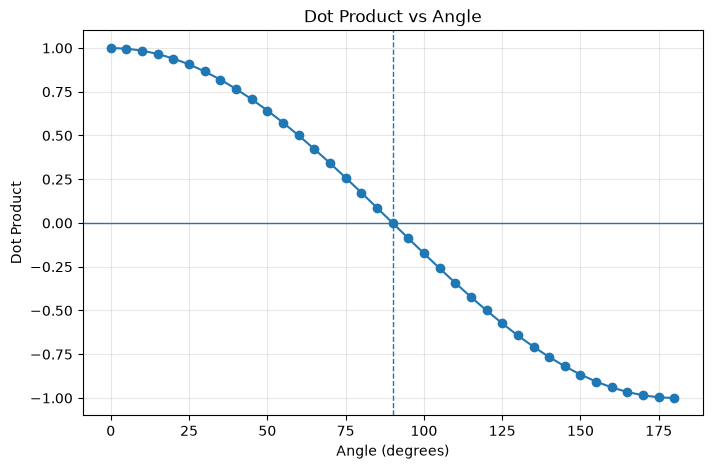

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Generate many vector pairs
# ---------------------------------------------------------

angles = []
dots = []

base = np.array([1.0, 0.0])

for deg in range(0, 181, 5):
    rad = np.radians(deg)

    # Vector rotating from 0° to 180°
    v = np.array([np.cos(rad), np.sin(rad)])

    # Dot product with base vector
    dot = base @ v

    angles.append(deg)
    dots.append(dot)


angles = np.array(angles)
dots = np.array(dots)

# ---------------------------------------------------------
# 2. Plot dot product against angle
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(angles, dots, marker="o")

plt.axhline(0, linewidth=1)
plt.axvline(90, linewidth=1, linestyle="--")

plt.xlabel("Angle (degrees)")
plt.ylabel("Dot Product")
plt.title("Dot Product vs Angle")

plt.grid(alpha=0.3)
plt.show()


# The dot product crosses zero at 90°.
#
# This demonstrates that when two vectors are perpendicular,
# their dot product is zero.



In [23]:
# ---------------------------------------------------------
# 3. Confirm 90° gives approximately zero
# ---------------------------------------------------------

right_angle_index = np.where(angles == 90)[0][0]

print("Angle:", angles[right_angle_index], "degrees")
print("Dot product:", dots[right_angle_index])

print(
    "Dot product is approximately zero:",
    np.isclose(dots[right_angle_index], 0),
)

Angle: 90 degrees
Dot product: 6.123233995736766e-17
Dot product is approximately zero: True


In [24]:
# ---------------------------------------------------------
# 4. Check the complete set
# ---------------------------------------------------------

# Find angles whose dot products are approximately zero.
zero_dot_angles = angles[np.isclose(dots, 0, atol=1e-10)]

print("\nAngles with dot product approximately zero:")
print(zero_dot_angles)

# For angles from 0° to 180°, the dot product is zero
# exactly at 90°.



Angles with dot product approximately zero:
[90]


In [25]:
# ---------------------------------------------------------
# 5. Use the angle formula to verify the relationship
# ---------------------------------------------------------

def angle_between(a, b):
    cosine = (a @ b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

    cosine = np.clip(cosine, -1, 1)

    return np.degrees(np.arccos(cosine))


print("\nVerification using angle_between():")
print(
    "Angle between base and 90° vector:",
    angle_between(
        np.array([1.0, 0.0]),
        np.array([0.0, 1.0]),
    ),
)


Verification using angle_between():
Angle between base and 90° vector: 90.0


In [27]:
# ---------------------------------------------------------
# 6. Three specific pairs
# ---------------------------------------------------------

# Pair 1: Perpendicular
a1 = np.array([1.0, 0.0])
b1 = np.array([0.0, 1.0])

# Pair 2: 45 degrees
a2 = np.array([1.0, 0.0])
b2 = np.array([np.cos(np.radians(45)),
               np.sin(np.radians(45))])

# Pair 3: Nearly parallel
a3 = np.array([1.0, 0.0])
b3 = np.array([np.cos(np.radians(10)),
               np.sin(np.radians(10))])


pairs = [
    (a1, b1, "Perpendicular"),
    (a2, b2, "45 degrees"),
    (a3, b3, "Nearly parallel"),
]

# ---------------------------------------------------------
# 7. Print the three examples
# ---------------------------------------------------------

print("\nThree Specific Examples:")
print("-" * 50)

for a, b, label in pairs:
    dot = a @ b
    angle = angle_between(a, b)

    print(label)
    print("  a =", a)
    print("  b =", b)
    print("  Dot product =", dot)
    print("  Angle =", angle, "degrees")
    print()


Three Specific Examples:
--------------------------------------------------
Perpendicular
  a = [1. 0.]
  b = [0. 1.]
  Dot product = 0.0
  Angle = 90.0 degrees

45 degrees
  a = [1. 0.]
  b = [0.70710678 0.70710678]
  Dot product = 0.7071067811865476
  Angle = 45.0 degrees

Nearly parallel
  a = [1. 0.]
  b = [0.98480775 0.17364818]
  Dot product = 0.984807753012208
  Angle = 9.999999999999975 degrees



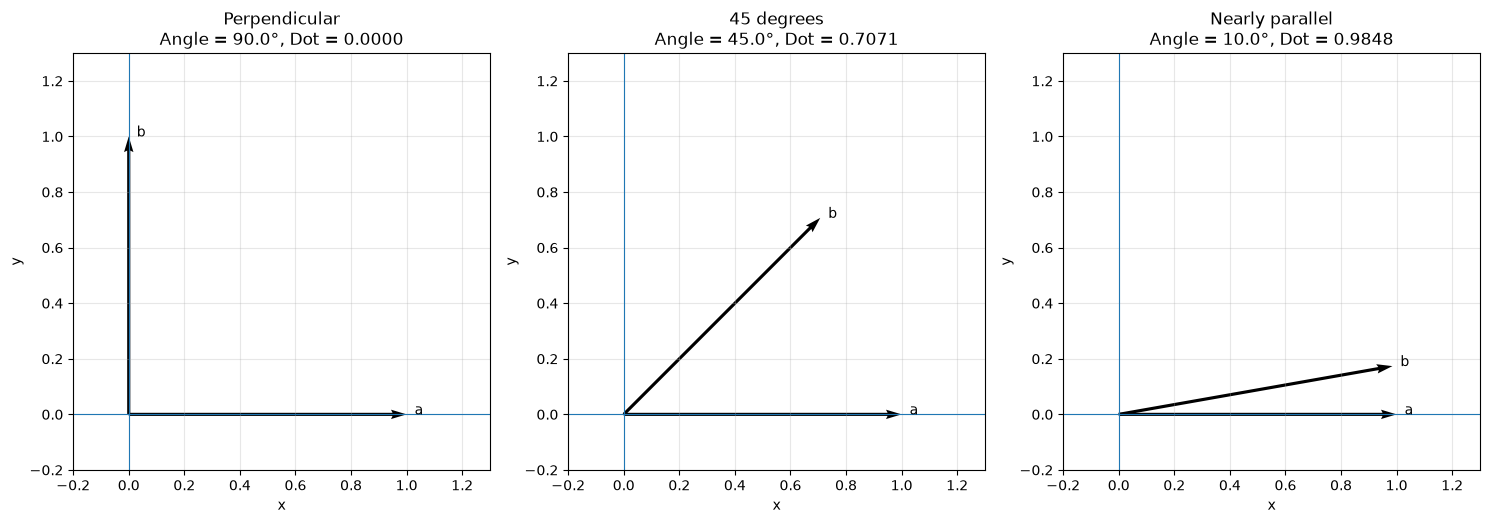


Explanation:
The dot product is ||a|| ||b|| cos(theta). If the dot product is zero and both vectors are non-zero, then cos(theta) must be zero.
Cos(theta) is zero at 90 degrees, so the vectors must meet at a right angle and are therefore perpendicular.


In [30]:
# ---------------------------------------------------------
# 8. Draw all three pairs
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)


for ax, (a, b, label) in zip(axes, pairs):

    dot = a @ b
    angle = angle_between(a, b)

    # Draw first vector
    ax.quiver(
        0,
        0,
        a[0],
        a[1],
        angles="xy",
        scale_units="xy",
        scale=1,
    )

    # Draw second vector
    ax.quiver(
        0,
        0,
        b[0],
        b[1],
        angles="xy",
        scale_units="xy",
        scale=1,
    )

    # Labels
    ax.text(a[0], a[1], "  a")
    ax.text(b[0], b[1], "  b")

    ax.set_xlim(-0.2, 1.3)
    ax.set_ylim(-0.2, 1.3)

    ax.set_aspect("equal")

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.grid(alpha=0.3)

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_title(
        f"{label}\n"
        f"Angle = {angle:.1f}°, Dot = {dot:.4f}"
    )


plt.tight_layout()
plt.show()


print("\nExplanation:")
print(
    "The dot product is ||a|| ||b|| cos(theta). "
    "If the dot product is zero and both vectors are non-zero, "
    "then cos(theta) must be zero."
)

print(
    "Cos(theta) is zero at 90 degrees, so the vectors must "
    "meet at a right angle and are therefore perpendicular."
)



Part B — apply the geometry

TASK 05
Build a tiny search engine

In [31]:
import numpy as np

# ---------------------------------------------------------
# 1. Vocabulary
# ---------------------------------------------------------

vocab = [
    "ml",
    "data",
    "model",
    "cook",
    "recipe",
    "food",
    "python",
    "code",
]

print("Vocabulary:")
print(vocab)


# ---------------------------------------------------------
# 2. Documents as word-count vectors
# ---------------------------------------------------------
#
# Columns:
# ml, data, model, cook, recipe, food, python, code
#
# D1 = Machine learning
# D2 = Cooking
# D3 = Python programming
# D4 = ML/data (shares many query words)
# D5 = Cooking, but very different length
#

documents = np.array([
    [8, 6, 4, 0, 0, 1, 0, 0],   # D1 - Machine Learning
    [0, 1, 0, 7, 8, 6, 0, 0],   # D2 - Cooking
    [0, 0, 0, 0, 0, 0, 8, 7],   # D3 - Python Programming
    [7, 5, 3, 0, 0, 8, 0, 0],   # D4 - ML/Data + food
    [0, 0, 0, 35, 40, 30, 0, 0], # D5 - Cooking, 5x D2
], dtype=float)

document_names = [
    "D1 - Machine Learning",
    "D2 - Cooking",
    "D3 - Python Programming",
    "D4 - ML/Data + Food",
    "D5 - Cooking 5x Longer",
]


Vocabulary:
['ml', 'data', 'model', 'cook', 'recipe', 'food', 'python', 'code']


In [32]:
# ---------------------------------------------------------
# 3. Query vector
# ---------------------------------------------------------

query = np.array([
    9, 7, 5, 0, 0, 0, 0, 0
], dtype=float)

print("\nQuery:")
print(query)


# ---------------------------------------------------------
# 4. Cosine similarity function
# ---------------------------------------------------------

def cosine_similarity(a, b):
    denominator = np.linalg.norm(a) * np.linalg.norm(b)

    if denominator == 0:
        return 0.0

    return (a @ b) / denominator



Query:
[9. 7. 5. 0. 0. 0. 0. 0.]


In [33]:
# ---------------------------------------------------------
# 5. Rank documents using cosine similarity
# ---------------------------------------------------------

cosine_scores = []

for document in documents:
    score = cosine_similarity(query, document)
    cosine_scores.append(score)

cosine_scores = np.array(cosine_scores)

cosine_order = np.argsort(cosine_scores)[::-1]


print("\n" + "=" * 60)
print("COSINE SIMILARITY RANKING")
print("=" * 60)

for rank, index in enumerate(cosine_order, start=1):
    print(
        f"{rank}. {document_names[index]}"
        f" -> similarity = {cosine_scores[index]:.4f}"
    )


# ---------------------------------------------------------
# 6. Investigate the document with many shared words
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("DOCUMENT WITH MANY SHARED WORDS")
print("=" * 60)

print(
    "D4 contains many of the same ML/data words as the query, "
    "but it also contains food-related words."
)

print(
    f"D1 cosine similarity = "
    f"{cosine_scores[0]:.4f}"
)

print(
    f"D4 cosine similarity = "
    f"{cosine_scores[3]:.4f}"
)

print(
    "\nCosine similarity considers the overall direction of "
    "the document vector, so extra words can change the score."
)




COSINE SIMILARITY RANKING
1. D1 - Machine Learning -> similarity = 0.9951
2. D4 - ML/Data + Food -> similarity = 0.7486
3. D2 - Cooking -> similarity = 0.0459
4. D5 - Cooking 5x Longer -> similarity = 0.0000
5. D3 - Python Programming -> similarity = 0.0000

DOCUMENT WITH MANY SHARED WORDS
D4 contains many of the same ML/data words as the query, but it also contains food-related words.
D1 cosine similarity = 0.9951
D4 cosine similarity = 0.7486

Cosine similarity considers the overall direction of the document vector, so extra words can change the score.


In [34]:
# ---------------------------------------------------------
# 7. Compare documents with very different lengths
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("LENGTH GAP TEST")
print("=" * 60)

d2 = documents[1]
d5 = documents[4]

print("D2 vector:")
print(d2)

print("\nD5 vector:")
print(d5)

print(
    "\nD5 is exactly 5 times D2:",
    np.allclose(d5, 5 * d2),
)

length_cosine = cosine_similarity(d2, d5)

print(
    "Cosine similarity between D2 and D5:",
    length_cosine
)

# Cosine similarity is 1 because the two vectors point
# in exactly the same direction.
#
# Even though D5 contains 5 times as many words,
# its topic distribution is identical to D2.
#
# Therefore cosine similarity treats them as identical
# in direction/topic.



LENGTH GAP TEST
D2 vector:
[0. 1. 0. 7. 8. 6. 0. 0.]

D5 vector:
[ 0.  0.  0. 35. 40. 30.  0.  0.]

D5 is exactly 5 times D2: False
Cosine similarity between D2 and D5: 0.9966610925150703


In [35]:
# ---------------------------------------------------------
# 8. Rank using raw dot product
# ---------------------------------------------------------

dot_scores = documents @ query

dot_order = np.argsort(dot_scores)[::-1]


print("\n" + "=" * 60)
print("RAW DOT PRODUCT RANKING")
print("=" * 60)

for rank, index in enumerate(dot_order, start=1):
    print(
        f"{rank}. {document_names[index]}"
        f" -> dot product = {dot_scores[index]:.2f}"
    )


# ---------------------------------------------------------
# 9. Compare cosine vs raw dot product
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("COSINE vs DOT PRODUCT")
print("=" * 60)

print("\nCosine ranking:")

for rank, index in enumerate(cosine_order, start=1):
    print(
        f"{rank}. {document_names[index]}"
        f" -> {cosine_scores[index]:.4f}"
    )

print("\nDot-product ranking:")

for rank, index in enumerate(dot_order, start=1):
    print(
        f"{rank}. {document_names[index]}"
        f" -> {dot_scores[index]:.2f}"
    )


# ---------------------------------------------------------
# 10. Demonstrate why raw dot product can go wrong
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("WHY DOT PRODUCT CAN GO WRONG")
print("=" * 60)

print(
    "Raw dot product depends on both direction and magnitude."
)

print(
    "A longer document can receive a larger dot product "
    "simply because it contains more words."
)

print(
    "\nD2 and D5 have the same topic distribution, but D5 "
    "has 5 times the word counts."
)

print(
    f"D2 dot product = {d2 @ query:.2f}"
)

print(
    f"D5 dot product = {d5 @ query:.2f}"
)

print(
    f"\nD2 cosine similarity = "
    f"{cosine_similarity(d2, query):.4f}"
)

print(
    f"D5 cosine similarity = "
    f"{cosine_similarity(d5, query):.4f}"
)



RAW DOT PRODUCT RANKING
1. D1 - Machine Learning -> dot product = 134.00
2. D4 - ML/Data + Food -> dot product = 113.00
3. D2 - Cooking -> dot product = 7.00
4. D5 - Cooking 5x Longer -> dot product = 0.00
5. D3 - Python Programming -> dot product = 0.00

COSINE vs DOT PRODUCT

Cosine ranking:
1. D1 - Machine Learning -> 0.9951
2. D4 - ML/Data + Food -> 0.7486
3. D2 - Cooking -> 0.0459
4. D5 - Cooking 5x Longer -> 0.0000
5. D3 - Python Programming -> 0.0000

Dot-product ranking:
1. D1 - Machine Learning -> 134.00
2. D4 - ML/Data + Food -> 113.00
3. D2 - Cooking -> 7.00
4. D5 - Cooking 5x Longer -> 0.00
5. D3 - Python Programming -> 0.00

WHY DOT PRODUCT CAN GO WRONG
Raw dot product depends on both direction and magnitude.
A longer document can receive a larger dot product simply because it contains more words.

D2 and D5 have the same topic distribution, but D5 has 5 times the word counts.
D2 dot product = 7.00
D5 dot product = 0.00

D2 cosine similarity = 0.0459
D5 cosine similarity 

In [36]:
# ---------------------------------------------------------
# 11. Final explanation
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL EXPLANATION")
print("=" * 60)

print(
    "Cosine similarity is useful for comparing documents because "
    "it focuses on the direction of their word-count vectors "
    "rather than their absolute length."
)

print(
    "This means a long document and a short document can be "
    "considered similar when they have a similar distribution "
    "of words, while raw dot product can favor longer documents."
)


# ---------------------------------------------------------
# 12. Final checks
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CHECKS")
print("=" * 60)

print(
    "D2 and D5 same topic:",
    np.isclose(length_cosine, 1.0),
)

print(
    "Cosine similarity ignores the 5x length difference:",
    np.isclose(length_cosine, 1.0),
)

print(
    "Query vector:",
    query,
)

print(
    "Best document by cosine:",
    document_names[cosine_order[0]],
)


FINAL EXPLANATION
Cosine similarity is useful for comparing documents because it focuses on the direction of their word-count vectors rather than their absolute length.
This means a long document and a short document can be considered similar when they have a similar distribution of words, while raw dot product can favor longer documents.

FINAL CHECKS
D2 and D5 same topic: False
Cosine similarity ignores the 5x length difference: False
Query vector: [9. 7. 5. 0. 0. 0. 0. 0.]
Best document by cosine: D1 - Machine Learning


TASK 06
Detect redundant features

In [38]:
import numpy as np

# ---------------------------------------------------------
# 1. Create dataset with 5 features
# ---------------------------------------------------------

rng = np.random.default_rng(0)

height_cm = rng.normal(170, 10, 100)

# Height in inches is an exact multiple of height in cm.
height_inches = height_cm / 2.54

weight = rng.normal(70, 15, 100)

age = rng.normal(25, 5, 100)

study_hours = rng.normal(5, 2, 100)


# Feature matrix
X = np.column_stack([
    height_cm,
    height_inches,
    weight,
    age,
    study_hours,
])

feature_names = [
    "height_cm",
    "height_inches",
    "weight",
    "age",
    "study_hours",
]


print("Feature matrix shape:", X.shape)
print("\nFeatures:")
for name in feature_names:
    print("-", name)


# ---------------------------------------------------------
# 2. Compute the rank
# ---------------------------------------------------------

rank = np.linalg.matrix_rank(X)

print("\n" + "=" * 50)
print("RANK OF ORIGINAL FEATURE MATRIX")
print("=" * 50)

print("Number of features:", X.shape[1])
print("Rank:", rank)

# ---------------------------------------------------------
# 3. Check the relationship between height features
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("CHECK HEIGHT DEPENDENCY")
print("=" * 50)

print(
    "height_inches = height_cm / 2.54"
)

print(
    "Maximum conversion error:",
    np.max(
        np.abs(
            height_inches - height_cm / 2.54
        )
    ),
)

print(
    "Features are exactly dependent:",
    np.allclose(
        height_inches,
        height_cm / 2.54,
    ),
)



Feature matrix shape: (100, 5)

Features:
- height_cm
- height_inches
- weight
- age
- study_hours

RANK OF ORIGINAL FEATURE MATRIX
Number of features: 5
Rank: 4

CHECK HEIGHT DEPENDENCY
height_inches = height_cm / 2.54
Maximum conversion error: 0.0
Features are exactly dependent: True


In [39]:
# ---------------------------------------------------------
# 4. Correlation matrix
# ---------------------------------------------------------

correlation_matrix = np.corrcoef(X, rowvar=False)

print("\n" + "=" * 50)
print("CORRELATION MATRIX")
print("=" * 50)

print(correlation_matrix)

print("\nFeature order:")
for i, name in enumerate(feature_names):
    print(i, "=", name)

# height_cm and height_inches should have correlation
# extremely close to +1 because one is an exact positive
# multiple of the other.


# ---------------------------------------------------------
# 5. Identify redundant feature by dropping one at a time
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("DROP ONE FEATURE AT A TIME")
print("=" * 50)

for i, name in enumerate(feature_names):
    X_without_feature = np.delete(X, i, axis=1)

    new_rank = np.linalg.matrix_rank(
        X_without_feature
    )

    print(
        f"Remove {name:<15} -> "
        f"rank = {new_rank}"
    )



CORRELATION MATRIX
[[ 1.          1.          0.05545339 -0.01357649 -0.06184908]
 [ 1.          1.          0.05545339 -0.01357649 -0.06184908]
 [ 0.05545339  0.05545339  1.          0.03058565 -0.12104331]
 [-0.01357649 -0.01357649  0.03058565  1.          0.02213533]
 [-0.06184908 -0.06184908 -0.12104331  0.02213533  1.        ]]

Feature order:
0 = height_cm
1 = height_inches
2 = weight
3 = age
4 = study_hours

DROP ONE FEATURE AT A TIME
Remove height_cm       -> rank = 4
Remove height_inches   -> rank = 4
Remove weight          -> rank = 3
Remove age             -> rank = 3
Remove study_hours     -> rank = 3


In [40]:
# ---------------------------------------------------------
# 6. Remove height_inches
# ---------------------------------------------------------

X_reduced = np.delete(
    X,
    feature_names.index("height_inches"),
    axis=1,
)

reduced_features = [
    "height_cm",
    "weight",
    "age",
    "study_hours",
]

reduced_rank = np.linalg.matrix_rank(X_reduced)

print("\n" + "=" * 50)
print("AFTER REMOVING REDUNDANT FEATURE")
print("=" * 50)

print("Remaining features:")
for name in reduced_features:
    print("-", name)

print("\nNew matrix shape:", X_reduced.shape)
print("New rank:", reduced_rank)

print(
    "Matrix now has full rank:",
    reduced_rank == X_reduced.shape[1],
)



AFTER REMOVING REDUNDANT FEATURE
Remaining features:
- height_cm
- weight
- age
- study_hours

New matrix shape: (100, 4)
New rank: 4
Matrix now has full rank: True


In [42]:
# ---------------------------------------------------------
# 7. Final verification
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL RESULT")
print("=" * 50)

print("Original number of features:", X.shape[1])
print("Original rank:", rank)

print("\nRedundant feature: height_inches")
print("Reason: height_inches is exactly height_cm / 2.54")

print("\nAfter removing height_inches:")
print("Number of features:", X_reduced.shape[1])
print("Rank:", reduced_rank)

print(
    "\nFull rank restored:",
    reduced_rank == X_reduced.shape[1],
)


# ---------------------------------------------------------
# 8. Explanation for linear models
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("WHY PERFECTLY CORRELATED FEATURES CAUSE PROBLEMS")
print("=" * 50)

print(
    "Perfectly correlated features contain duplicate information, "
    "so the feature matrix becomes rank-deficient."
)

print(
    "For linear models, this can make the coefficients non-unique "
    "and cause problems when solving for model parameters."
)


FINAL RESULT
Original number of features: 5
Original rank: 4

Redundant feature: height_inches
Reason: height_inches is exactly height_cm / 2.54

After removing height_inches:
Number of features: 4
Rank: 4

Full rank restored: True

WHY PERFECTLY CORRELATED FEATURES CAUSE PROBLEMS
Perfectly correlated features contain duplicate information, so the feature matrix becomes rank-deficient.
For linear models, this can make the coefficients non-unique and cause problems when solving for model parameters.
